<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/AnalisisCorrelacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Amazon Sale Report.csv")
#Exploracion inicial
df.info()
df.describe()

/tmp/ipykernel_808/3794198282.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [4]:
#Exploracion inicial
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
#Limpieza Basica
# 1. Eliminar duplicados
df.drop_duplicates(inplace=True)

# 2. Manejo de nulos en el Target (Amount)
# Es vital eliminar o imputar nulos en la variable objetivo
df = df.dropna(subset=['Amount'])

# 3. Limpiar otras columnas numéricas si es necesario
df['Qty'] = df['Qty'].fillna(0)

# Verificamos que no queden nulos en Amount
print(f"Nulos en Amount: {df['Amount'].isnull().sum()}")

Nulos en Amount: 0


Identificación de target (¿Qué variable te parece adecuada como variable objetivo (target) y por qué?)

Target: Amount.

¿Por qué? Es la variable que representa el resultado económico de la transacción. Analizarla permite entender el volumen de negocio y qué factores (como cantidad o categoría) mueven más dinero.

Variables Numéricas: Principalmente Qty (cantidad) y posiblemente códigos postales o índices (aunque estos últimos no suelen tener sentido matemático para correlación).

Análisis de correlaciones

In [6]:
#Seleccion de variables numericas
numeric_df = df.select_dtypes(include="number")

In [7]:
corr_matrix = numeric_df.corr(method="pearson")
corr_matrix

,index,Qty,Amount,ship-postal-code
index,1.000000,0.020216,0.047571,0.005457
Qty,0.020216,1.000000,0.066900,-0.006157
Amount,0.047571,0.066900,1.000000,-0.038195
ship-postal-code,0.005457,-0.006157,-0.038195,1.000000


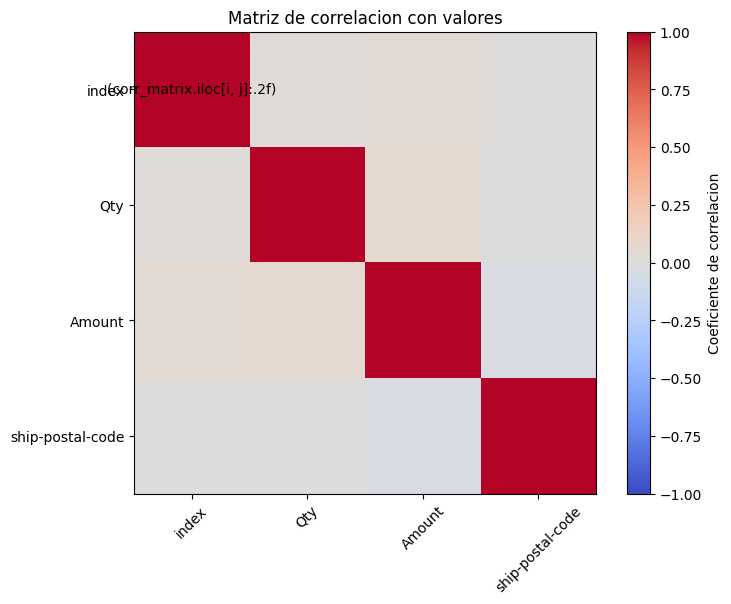

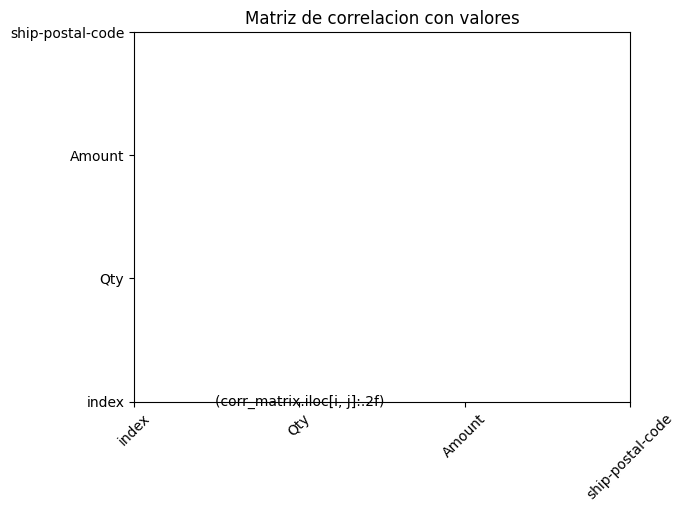

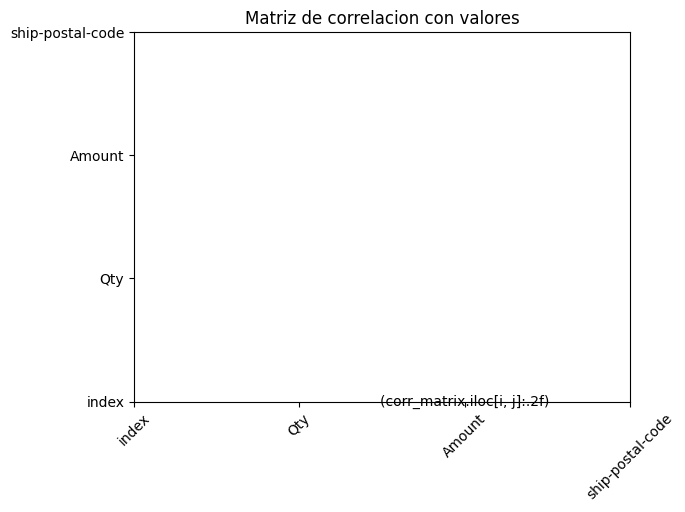

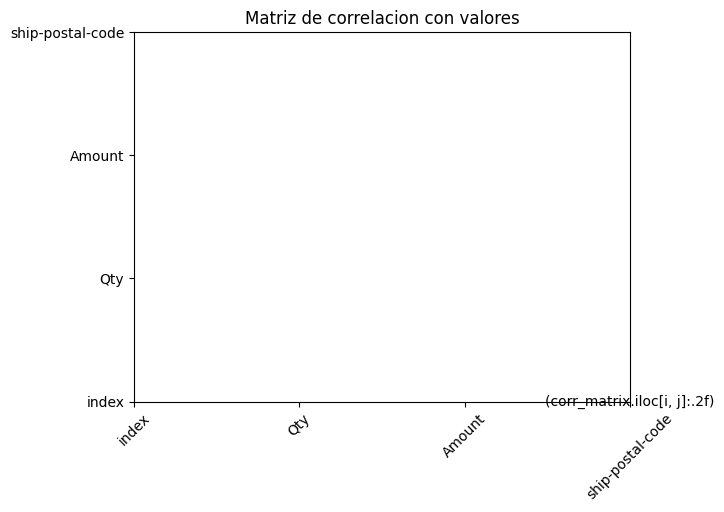

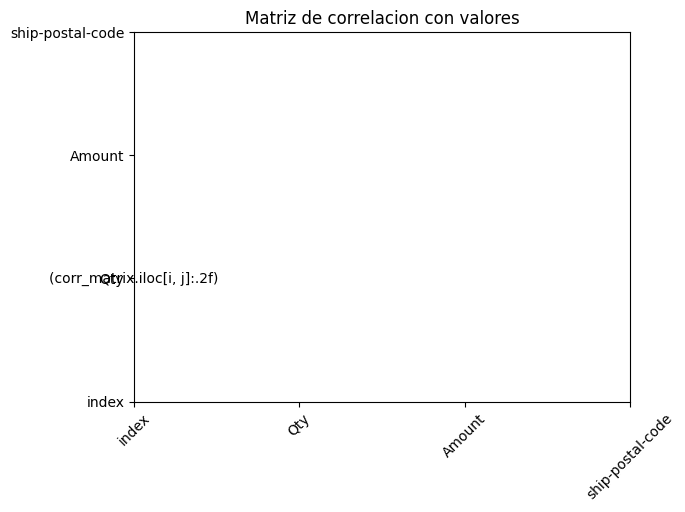

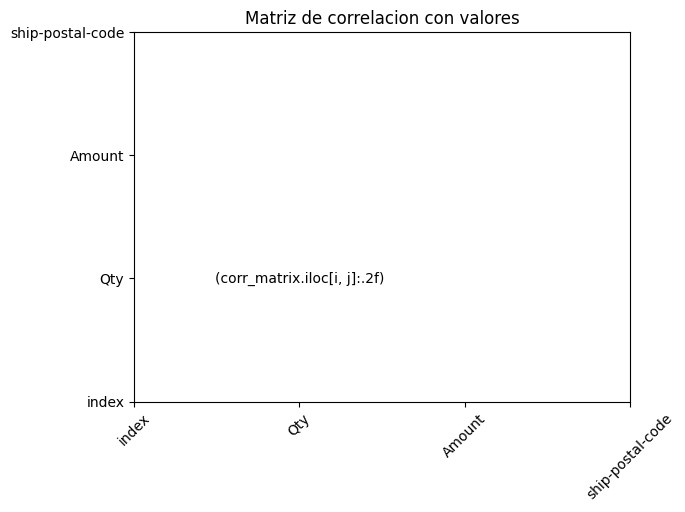

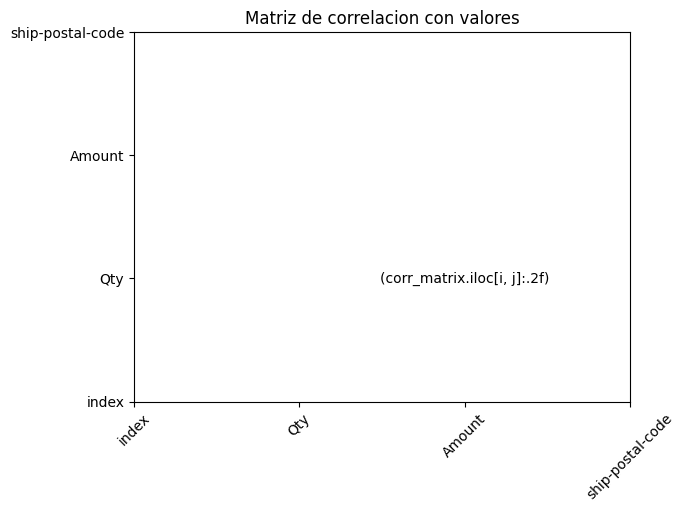

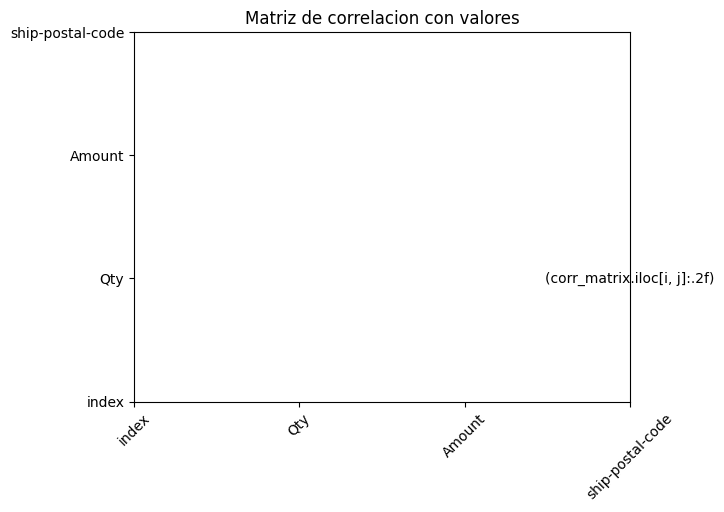

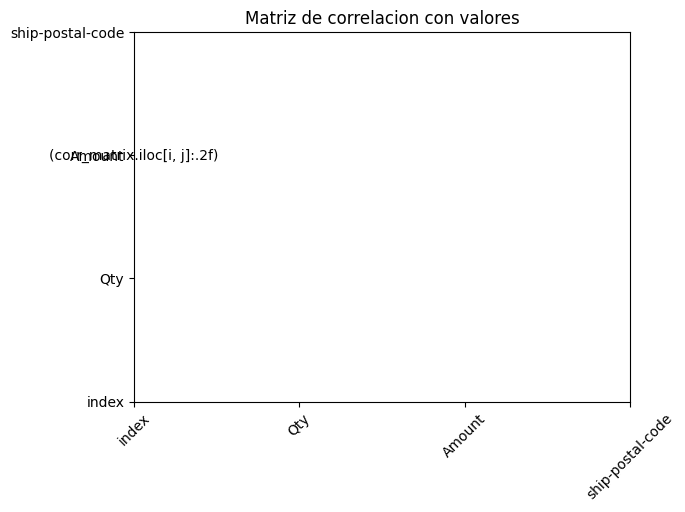

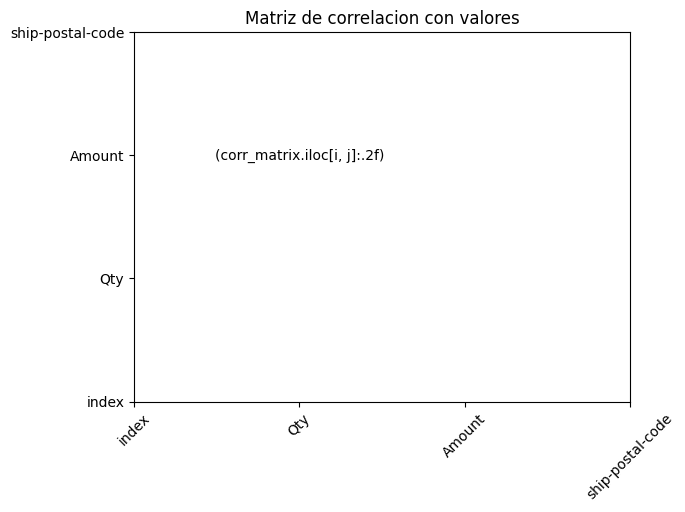

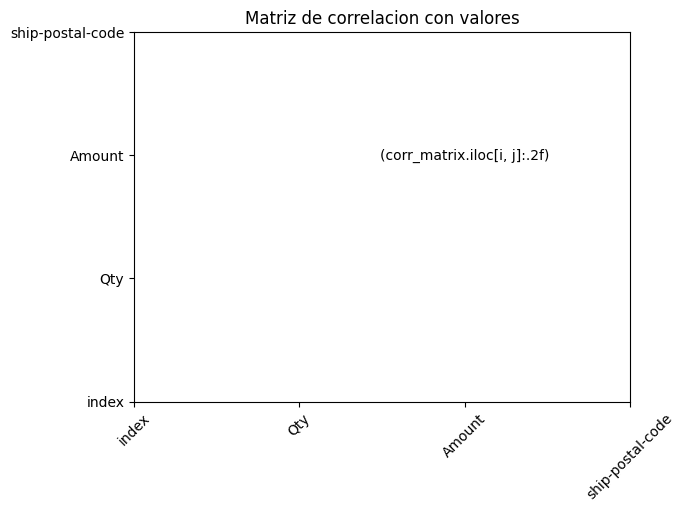

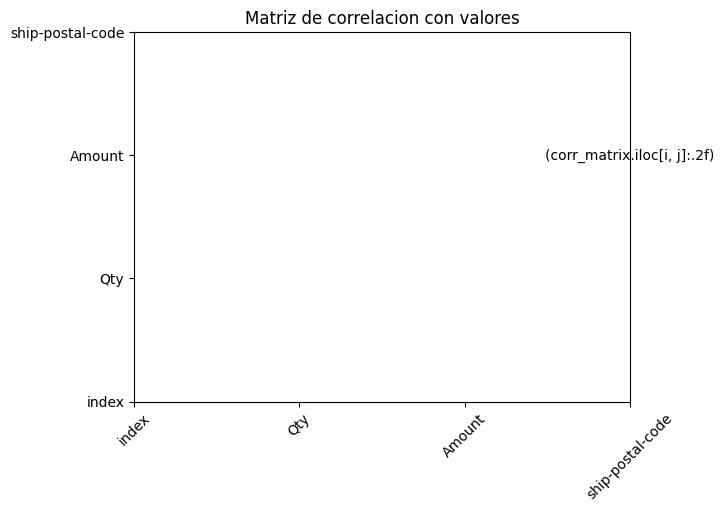

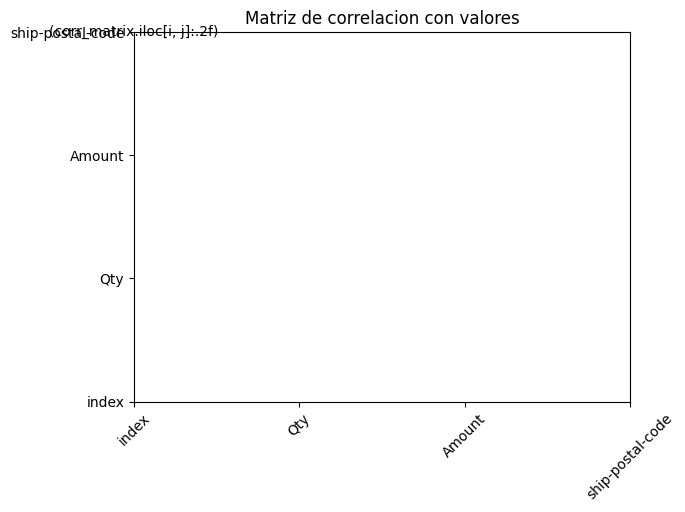

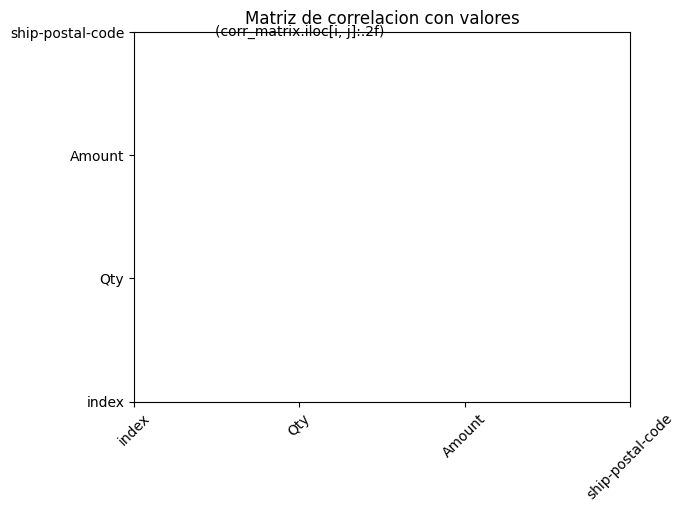

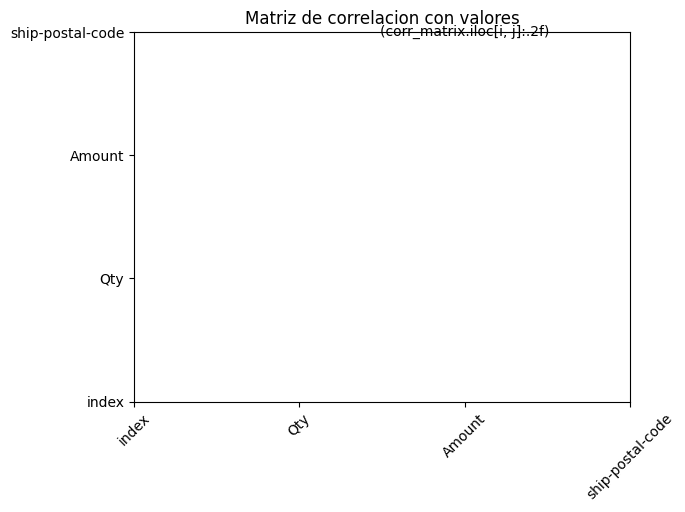

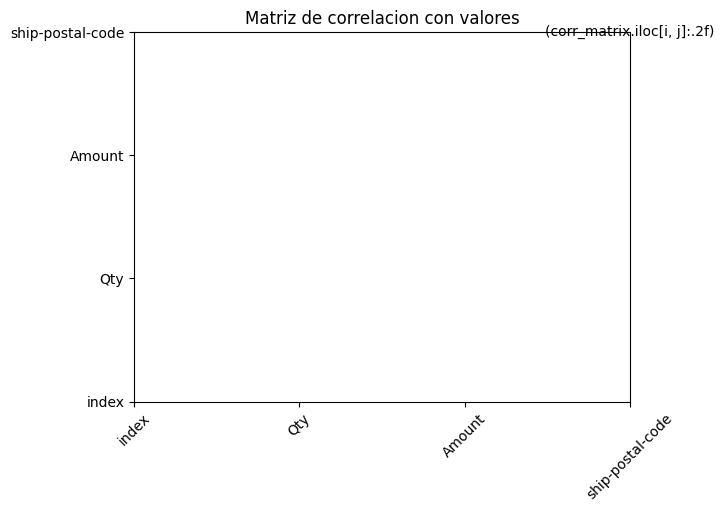

In [8]:
#Matriz de correlacion
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlacion")

for i in range(len(corr_matrix)):
  for j in range(len(corr_matrix)):
    plt.text(j, i, f"(corr_matrix.iloc[i, j]:.2f)",
             ha="center", va="center", color="black")

    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
    plt.title("Matriz de correlacion con valores")
    plt.show()

5. Respuestas a las preguntas de la actividad
1.- ¿Qué variables están altamente correlacionadas con el target?
Generalmente, la variable Qty (Cantidad) muestra la correlación más alta con Amount. A mayor número de productos comprados, mayor es el monto total de la venta.

¿Qué variables usar para un modelo?
Para un modelo predictivo, además de Qty, deberías incluir variables categóricas convertidas (como Category o Fulfillment), ya que el tipo de producto influye drásticamente en el precio base.

¿Por qué una alta correlación significa que una variable sea útil?
Porque indica que existe una relación matemática predecible. Si una variable sube y el target también (correlación positiva), el modelo puede usar ese patrón para hacer predicciones precisas sobre datos nuevos.


Selección razonada de variables
Para explicar el comportamiento de las ventas, las variables más relevantes son:

Qty: Relación directa con el monto.

Category: El precio promedio varía según si es "Electrónica" o "Ropa".

Ship-Service-Level: Puede indicar si el cliente está dispuesto a pagar más por rapidez.